In [1]:
import spikeinterface.full as si
from pathlib import Path

In [2]:
# PATHS (set here when running standalone; overridden by main_pipeline)
try:
    mcs_file
    base_folder
except NameError:
    mcs_file    = Path(r'C:\Users\labuser\Ilaria\Project\Multi Channel DataManager\2026-03-27T14-50-46McsRecording_E-00218.h5')
    base_folder = Path(r'C:\Users\labuser\Ilaria\Project\Pipeline_project\mcs_output')

In [3]:
# MCS-SPECIFIC PARAMETERS 
use_raw = False   # False → .h5 (Multi Channel DataManager export); True → .raw binary

freq_min       = 200.    # highpass cutoff (Hz)
cref_operator  = 'median'
cref_reference = 'global'

# SORTER (set in main_pipeline; fallback when running standalone)
try:
    sorter = SORTER_MCS
except NameError:
    sorter = 'spykingcircus2'   # 'mountainsort5' | 'spykingcircus2'

# UNIT REFINEMENT flag (set in main_pipeline; fallback when running standalone)
try:
    _run_ur = RUN_UNITREFINE
except NameError:
    _run_ur = False   # UnitRefine not needed for MEA/MCS data by default

In [4]:
# LOAD 
if use_raw:
    raw_rec = si.read_mcsraw(mcs_file)
else:
    raw_rec = si.read_mcsh5(mcs_file)
print(raw_rec)

MCSH5RecordingExtractor: 60 channels - 25000.000000 Hz - 1 segments - 1,495,000 samples - 59.80s 
                         int32 dtype - 342.18 MiB
  file_path: C:\Users\labuser\Ilaria\Project\Multi Channel DataManager\2026-03-27T14-50-46McsRecording_E-00218.h5


In [5]:
# PROBE SETUP
# Priority: (1) geometry embedded in file → (2) generic rectangular grid
# Note: multichannelsystems is not in the probeinterface library, so no named-probe lookup.
import math
import numpy as np
from probeinterface import generate_multi_columns_probe

n_ch = raw_rec.get_num_channels()

# 1 — check if read_mcsh5 already attached electrode positions from the file
if raw_rec.get_property('contact_vector') is not None:
    print(f"Probe geometry found in file — {n_ch} channels, using as-is.")
else:
    # 2 — generic rectangular grid: find factor pair closest to square
    def _best_grid(n):
        best = (1, n)
        for c in range(1, int(n ** 0.5) + 1):
            if n % c == 0:
                best = (c, n // c)
        return best

    n_cols, n_rows = _best_grid(n_ch)
    probe = generate_multi_columns_probe(
        num_columns=n_cols,
        num_contact_per_column=n_rows,
        xpitch=200,   # µm — update to match your MEA electrode pitch
        ypitch=200,
    )
    probe.set_device_channel_indices(np.arange(n_ch))
    raw_rec = raw_rec.set_probe(probe, group_mode='by_probe')
    print(f"No probe geometry in file — using generic {n_cols}×{n_rows} grid (200 µm pitch).")

No probe geometry in file — using generic 6×10 grid (200 µm pitch).


In [6]:
# PREPROCESSING 
rec1 = si.highpass_filter(raw_rec, freq_min=freq_min)
bad_channel_ids, _ = si.detect_bad_channels(rec1)
rec2 = rec1.remove_channels(bad_channel_ids)
rec  = si.common_reference(rec2, operator=cref_operator, reference=cref_reference)
print(rec)

CommonReferenceRecording: 36 channels - 25000.000000 Hz - 1 segments - 1,495,000 samples - 59.80s 
                          int32 dtype - 205.31 MiB


C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\preprocessing\detect_bad_channels.py:300: UserWarning: Over 1/3 of channels are detected as bad. In the presence of a highnumber of dead / noisy channels, bad channel detection may fail (good channels may be erroneously labeled as dead).
  warnings.warn(


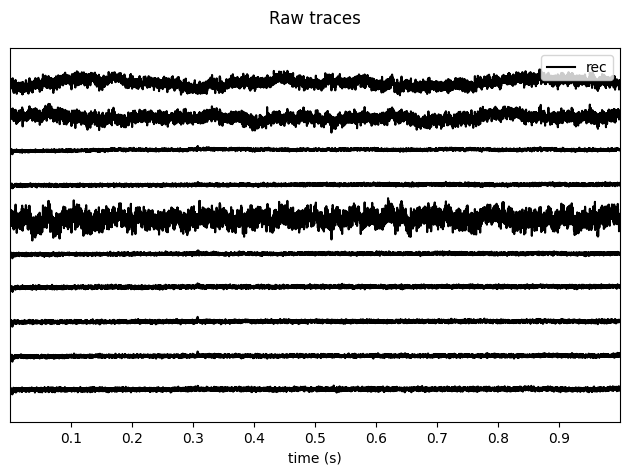

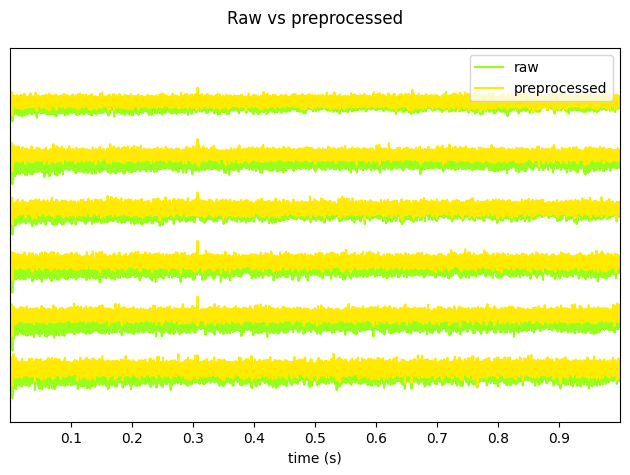

In [7]:
# TRACES VISUALIZATION
import re
import matplotlib.pyplot as plt
import spikeinterface.widgets as sw

_fs = raw_rec.get_sampling_frequency()
raw_2s = raw_rec.frame_slice(0, int(2 * _fs))
rec_2s = rec.frame_slice(0, int(2 * _fs))

# natural sort so Ch1, Ch2, Ch3 ... Ch10, Ch11 (not Ch1, Ch10, Ch11 ...)
_nat_key = lambda s: [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', s)]
_sorted_ch_ids = sorted(raw_rec.channel_ids, key=_nat_key)

# channels that survived bad-channel removal (needed for the comparison plot)
_good_ch_ids = [cid for cid in _sorted_ch_ids if cid in set(rec.channel_ids)]

# raw traces — first 10 channels in natural order
sw.plot_traces(raw_2s, channel_ids=_sorted_ch_ids[:10], mode='line', backend='matplotlib')
plt.suptitle('Raw traces')
plt.tight_layout()
plt.show()

# raw vs preprocessed — only channels present in both recordings
sw.plot_traces({'raw': raw_2s, 'preprocessed': rec_2s},
               channel_ids=_good_ch_ids[:6], mode='line', backend='matplotlib')
plt.suptitle('Raw vs preprocessed')
plt.tight_layout()
plt.show()

In [8]:
# SPIKE SORTING
import gc, shutil, json

job_kwargs = dict(n_jobs=4, chunk_duration='1s', progress_bar=True)

_preprocess_dir = base_folder / 'preprocess'
_sorter_dir     = base_folder / f'sorting_{sorter}'

# Release any analyzer left from a previous run — it keeps the preprocess binary
# memory-mapped on Windows, which blocks file deletion on re-run.
try:
    del analyzer
except NameError:
    pass
gc.collect()

def _si_folder_valid(folder):
    """True if folder contains a complete SpikeInterface saved object."""
    if not folder.exists():
        return False
    # saved recording / sorting (si v0.94–0.102+)
    if any((folder / f).exists() for f in ('si_folder.json', 'cached.json', 'cached.pkl', 'cached.pickle')):
        return True
    # sorter output folder (all three marker files must exist, log must show no error)
    if ((folder / 'sorter_output').is_dir()
            and (folder / 'spikeinterface_params.json').exists()
            and (folder / 'spikeinterface_log.json').exists()):
        with open(folder / 'spikeinterface_log.json') as _f:
            _log = json.load(_f)
        return not _log.get('error', False)
    return False

def _safe_rmtree(folder):
    """Delete a folder, raising a clear message if Windows still has a file locked."""
    try:
        shutil.rmtree(folder)
    except PermissionError:
        raise RuntimeError(
            f"Cannot delete '{folder.name}' — a file is still locked by another process.\n"
            "If the spikeinterface_gui is open, close it.\n"
            "Then restart the Jupyter kernel and re-run."
        )

# ── Preprocessed binary ──────────────────────────────────────────────────────
if _si_folder_valid(_preprocess_dir):
    rec = si.load(_preprocess_dir)
    print(f"Loaded cached preprocessed recording from '{_preprocess_dir.name}'")
else:
    if _preprocess_dir.exists():           # incomplete folder from a failed previous save
        _safe_rmtree(_preprocess_dir)
    # n_jobs=1: Windows HDF5 locking prevents multiple workers opening the .h5 simultaneously
    rec = rec.save(folder=_preprocess_dir, format='binary',
                   n_jobs=1, chunk_duration='1s', progress_bar=True)

# ── Spike sorting ────────────────────────────────────────────────────────────
if _si_folder_valid(_sorter_dir):
    sorting = si.load(_sorter_dir)
    print(f"Loaded cached sorting from '{_sorter_dir.name}'")
else:
    if _sorter_dir.exists():
        _safe_rmtree(_sorter_dir)
    sorting = si.run_sorter(sorter, rec, folder=_sorter_dir, verbose=True)

print(sorting)

Loaded cached preprocessed recording from 'preprocess'
Loaded cached sorting from 'sorting_spykingcircus2'
NumpyFolder (NumpyFolderSorting): 24 units - 1 segments - 25.0kHz


In [ ]:
# ANALYSIS & UNIT REFINEMENT
import sys, subprocess, pandas as pd
import matplotlib.pyplot as plt
import spikeinterface.curation as sc
import spikeinterface.widgets as sw

# ── Remove units with too few spikes ─────────────────────────────────────────
# The GUI scatter view calls np.min(np.diff(np.unique(amplitudes))), which
# raises ValueError on an empty array when all spikes of a unit share the
# same amplitude value — most commonly units with only 1 spike.
_min_spikes = 2
_valid_units = [uid for uid in sorting.unit_ids
                if sorting.get_unit_spike_train(uid, segment_index=0).size >= _min_spikes]
if len(_valid_units) < len(sorting.unit_ids):
    print(f"Dropping {len(sorting.unit_ids) - len(_valid_units)} unit(s) with <{_min_spikes} spikes.")
    sorting = sorting.select_units(_valid_units)

# ── Core extensions (always computed — needed for the interactive viewer) ────
analyzer = si.create_sorting_analyzer(sorting=sorting, recording=rec, format="memory")
analyzer.compute([
    "random_spikes",
    "waveforms",
    "templates",
    "noise_levels",
    "spike_amplitudes",
    "principal_components",
    "spike_locations",
    "unit_locations",
    "quality_metrics",
])

# ── UnitRefine (optional — only for SpikeGLX / linear-probe data) ───────────
if _run_ur:
    # auto-install dependencies if missing
    for _pkg in ["huggingface_hub", "skops"]:
        try:
            __import__(_pkg)
        except ModuleNotFoundError:
            subprocess.run([sys.executable, "-m", "pip", "install", _pkg], check=True)

    # include_multi_channel_metrics=False: spread/velocity metrics assume a linear probe
    analyzer.compute("template_metrics", include_multi_channel_metrics=False)

    # Stage 1 — noise vs neural
    noise_df = sc.auto_label_units(
        sorting_analyzer=analyzer,
        repo_id="SpikeInterface/UnitRefine_noise_neural_classifier",
        trust_model=True,
    )
    # Stage 2 — SUA vs MUA
    sua_mua_df = sc.auto_label_units(
        sorting_analyzer=analyzer,
        repo_id="SpikeInterface/UnitRefine_sua_mua_classifier",
        trust_model=True,
    )

    final_labels = noise_df["prediction"].copy()
    neural_mask  = final_labels == "neural"
    final_labels[neural_mask] = sua_mua_df["prediction"][neural_mask]

    print(final_labels.value_counts())
    print(f"\nSUA  : {(final_labels == 'sua').sum()}")
    print(f"MUA  : {(final_labels == 'mua').sum()}")
    print(f"Noise: {(final_labels == 'noise').sum()}")

    _label_colors = {'sua': 'green', 'mua': 'orange', 'noise': 'red'}
    unit_colors = {uid: _label_colors[lbl] for uid, lbl in final_labels.items()}
    w = sw.plot_unit_templates(analyzer, unit_colors=unit_colors)
    w.figure.suptitle("UnitRefine labelling  (green=SUA · orange=MUA · red=noise)")
    plt.tight_layout()
    plt.show()

    final_labels.rename("unitrefine_label").to_csv(base_folder / 'curation_labels.csv', header=True)
    print(f"\nGood (SUA) units saved to curation_labels.csv")

print(f"Analyzer ready — {len(analyzer.unit_ids)} units")

In [ ]:
# QUALITY METRICS
qm = analyzer.get_extension("quality_metrics").get_data()
print(qm)
qm.to_csv(base_folder / 'quality_metrics.csv')
print(f"Quality metrics saved → {base_folder / 'quality_metrics.csv'}")

In [10]:
# INTERACTIVE VIEWER (sigui)
# shows waveforms, ISI, amplitudes, probe map — click any unit to inspect
import spikeinterface_gui
spikeinterface_gui.run_mainwindow(analyzer)

C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\postprocessing\template_similarity.py:345: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  overlapping_ids = overlapping_j_list[i]
